# Plan de l'Aiguille (Chamonix-Mont-Blanc)

## Chargement des librairies

In [1]:
import os
import sys

# Ajout dans la variable PATH du système du chemin où est installée la librairie tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)
# Alias pour tracklib
import tracklib as tkl

# Ajout dans la variable PATH du système du chemin où est installée la librairie footprint2graph
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import matplotlib.pyplot as plt
import os
import time

from footprint2graph import footprint2grap
from footprint2graph import read_config

from footprint2graph.util.Outdoorvision import load_raw_tracks_split

## Chargement des paramètres

In [3]:
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('  Generate a footprint graph                                         ')
print ('             from hiking trajectories                                ')
print ("             in the Plan de l'Aiguille, dans la vallée de Chamonix, summer 2024.  ")
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('')


""" ======================================================================= """
"""     Load parameters                                                     """
"""                                                                         """

config_path = r'/home/md_vandamme/7_LIB/footprint2graph/data/config_plan_de_l_aiguille.yml'
config = read_config(config_path)


print('Paramètres relevés dans la configuration: ')
print ('Résultats enregistrés dans le répertoire: ', config['output']['RESULT_PATH'])

NBITER = int(config['graph_construction']['NUM_ITERATIONS'])
print ('Number of iterations: ', NBITER)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
  Generate a footprint graph                                         
             from hiking trajectories                                
             in the Plan de l'Aiguille, dans la vallée de Chamonix, summer 2024.  
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Paramètres relevés dans la configuration: 
Résultats enregistrés dans le répertoire:  /home/md_vandamme/4_RESEAU/ZTEMPZ3/
Number of iterations:  2


## Chargement des données

Les données proviennent de la plateforme Outdoorvision. Après avoir été formatées au format CSV, elles sont chargées dans une collection qui servira d’entrée au pipeline.

In [4]:
""" ======================================================================= """
"""     Chargement de la collection de traces                               """
"""                                                                         """

# chemin où sont stockés les traces Outdoorvision:
tracespathsource = r'/home/md_vandamme/5_GPS/OV/CHAM/walk/'

# Paramètre : Coordonnées de la zone d'étude sur laquelle on construit le réseau
#                           Polygone sous la forme d'un tableau de X et de Y
X = [1000852, 1001838, 1001852, 1000853, 1000852]
Y = [6541520,  6541524,  6540842,  6540839,  6541520]

fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})
collection = load_raw_tracks_split(config['output']['RESULT_PATH'],
                                   tracespathsource, fmt, X, Y)

Loading and split outdoorvision track data...
Reading track data...
     Number files to load:  21211
Starting split ...
     1000 / 21211
     2000 / 21211
     3000 / 21211
     4000 / 21211
     5000 / 21211
     6000 / 21211
     7000 / 21211
     8000 / 21211
     9000 / 21211
     10000 / 21211
     11000 / 21211
     12000 / 21211
     13000 / 21211
     14000 / 21211
     15000 / 21211
     16000 / 21211
     17000 / 21211
     18000 / 21211
     19000 / 21211
     20000 / 21211
     21000 / 21211
     Number of tracks after split: 631


## Lancement du pipeline

In [5]:
# 
footprint2grap(config, collection, 'ERROR')

-----------------------------------------------------------------
-----------------------------------------------------------------
              ITERATION  1
-----------------------------------------------------------------
-----------------------------------------------------------------
Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks to resample:  688
Stage 1 finished: segmentation and resampling.
Starting rasterization and vectorization (iteration 1) 



100% (341 of 341) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (846 of 846) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (403 of 403) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (663 of 663) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1273 of 1273) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (621 of 621) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (618 of 618) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2711 of 2711) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1113 of 1113) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (967 of 967) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (963 of 963) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


Stage 2 completed: rasterization and vectorization.
Starting topology creation for the network
    /home/md_vandamme/4_RESEAU/ZTEMPZ3/network/tmp_in.csv not exists
    /home/md_vandamme/4_RESEAU/ZTEMPZ3/network/tmp_out.csv not exists


 50% (16 of 32) |############            | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (32 of 32) |########################| Elapsed Time: 0:00:00 Time:  0:00:000000
100% (32 of 32) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


...

 81% (66 of 81) |###################     | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (81 of 81) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (81 of 81) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Building [100 x 87] spatial index...
Stage 3 completed: adding topology to the skeleton.
Starting map-matching, aggregation, and conflation of GNSS trajectories.
Stage 4 completed: map-matching, aggregation, and conflation.
Merging the mobility network with the result of iteration 2.


100% (40 of 40) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Building [100 x 74] spatial index...
End building the mobility network.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
                           FIN                                       
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## Visualisation du réseau de mobilité pédestre final

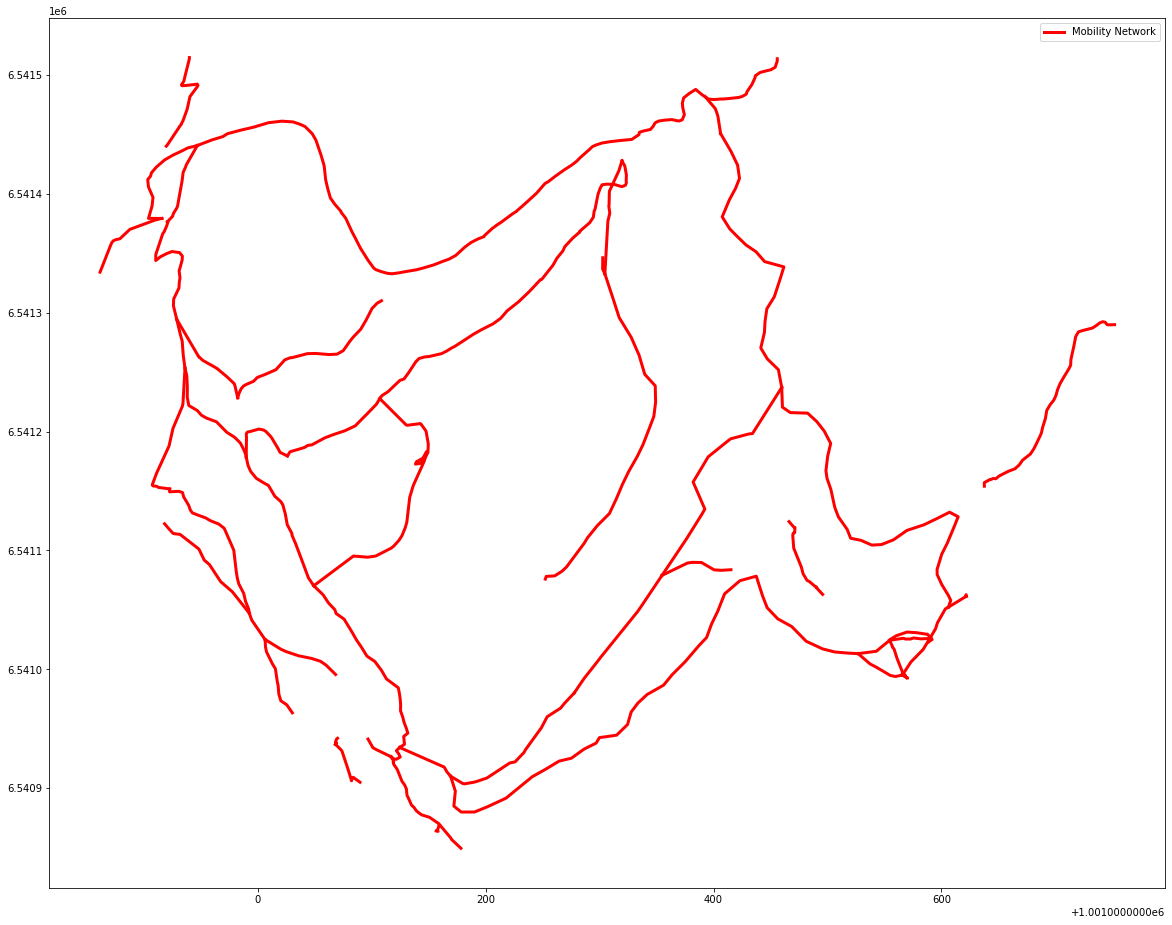

In [6]:
from footprint2graph.util.PlotRes import plotResultatFinal

plotResultatFinal(config['output']['RESULT_PATH'], '2')